# 02 - Clasificacion Supervisada: Manglar / Camaronera / Agua
## Proyecto Boomerang - SpaceHACK 2026

Clasificacion supervisada con Random Forest sobre Sentinel-2.
Migrado del script original en GEE (JavaScript) a Python con geemap.
Mejorado con indices espectrales adicionales y accuracy assessment.

In [27]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np

ee.Initialize(project='august-tower-470819-s6')

In [28]:
# --- ROI ---
roi = ee.Geometry.Polygon([[
    [-80.23433322304784, -2.581044464678974],
    [-80.09837741250097, -2.581044464678974],
    [-80.09837741250097, -2.4212085241315013],
    [-80.23433322304784, -2.4212085241315013],
    [-80.23433322304784, -2.581044464678974]
]])

In [29]:
# --- Cargar Sentinel-2 2024 (imagen mas reciente) ---
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median()
    .clip(roi))

# --- Calcular indices espectrales como features adicionales ---
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = s2.normalizedDifference(['B3', 'B8']).rename('NDWI')
mndwi = s2.normalizedDifference(['B3', 'B11']).rename('MNDWI')

# SAVI con L=0.5
nir = s2.select('B8')
red = s2.select('B4')
savi = nir.subtract(red).divide(nir.add(red).add(0.5 * 10000)).multiply(1.5).rename('SAVI')

# Imagen compuesta con bandas originales + indices
composite = s2.addBands([ndvi, ndwi, mndwi, savi])

print(f'Bandas del composite: {composite.bandNames().getInfo()}')

# --- Mapa interactivo para recolectar puntos ---
# Usa la herramienta de MARCADOR (pin) en la barra de dibujo del mapa
# para colocar puntos. Los puntos se guardan en Map.user_rois
Map = geemap.Map(center=[-2.50, -80.17], zoom=13)
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, 'Sentinel-2 RGB')
Map.addLayer(s2, {'bands': ['B8', 'B4', 'B3'], 'max': 5000}, 'Falso Color (NIR)', shown=False)
Map.addLayer(ndvi, {'min': -0.1, 'max': 0.8, 'palette': ['red','yellow','green','darkgreen']}, 'NDVI', shown=False)
Map

Bandas del composite: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDWI', 'MNDWI', 'SAVI']


Map(center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Recoleccion Interactiva de Puntos de Entrenamiento

**3 celdas separadas, una por clase. No se sobreescriben entre si.**

1. Dibuja puntos de **MANGLAR** en el mapa -> ejecuta celda "Guardar MANGLAR"
2. Borra los marcadores del mapa (icono de papelera en la barra de dibujo)
3. Dibuja puntos de **CAMARONERA** -> ejecuta celda "Guardar CAMARONERA"
4. Borra marcadores
5. Dibuja puntos de **AGUA** -> ejecuta celda "Guardar AGUA"

**Tips:**
- Activa la capa "Falso Color (NIR)" para ver mejor el manglar (rojo brillante)
- Las camaroneras son rectangulos geometricos con agua turbia
- El agua abierta se ve azul oscuro en RGB

In [31]:
# =============================================================
# INICIALIZAR RECOLECCION DE PUNTOS
# =============================================================
import json

class_labels = {'mangrove': 1, 'shrimp': 2, 'water': 3}

# Puntos de AGUA ya recolectados (52 puntos de la sesion anterior)
water_coords_backup = [
    [-80.1581, -2.5600], [-80.1524, -2.5494], [-80.1359, -2.5678], [-80.1514, -2.5413],
    [-80.1569, -2.5345], [-80.1581, -2.5264], [-80.1522, -2.5204], [-80.1434, -2.5125],
    [-80.1457, -2.5055], [-80.1449, -2.4972], [-80.1386, -2.4897], [-80.1083, -2.4957],
    [-80.1040, -2.4862], [-80.1024, -2.4797], [-80.1030, -2.4737], [-80.1040, -2.4680],
    [-80.1770, -2.5504], [-80.1565, -2.5762], [-80.1955, -2.5422], [-80.1748, -2.5330],
    [-80.2058, -2.5305], [-80.1882, -2.5239], [-80.1993, -2.5185], [-80.2138, -2.5284],
    [-80.1869, -2.5164], [-80.1765, -2.5108], [-80.1615, -2.5150], [-80.1617, -2.5219],
    [-80.1634, -2.5084], [-80.1636, -2.5030], [-80.1724, -2.5026], [-80.1782, -2.5046],
    [-80.1741, -2.4965], [-80.1815, -2.4932], [-80.1760, -2.4873], [-80.1902, -2.4933],
    [-80.1946, -2.4947], [-80.1973, -2.4990], [-80.1989, -2.5048], [-80.2016, -2.5106],
    [-80.1926, -2.5179], [-80.1786, -2.4857], [-80.2302, -2.5406], [-80.2231, -2.5394],
    [-80.2234, -2.5343], [-80.2299, -2.5219], [-80.1245, -2.4550], [-80.1279, -2.4444],
    [-80.1423, -2.4396], [-80.1562, -2.4420], [-80.1622, -2.4335], [-80.1699, -2.4266],
]

# Siempre cargar los 52 puntos de agua del backup
try:
    collected_points
except NameError:
    collected_points = {'mangrove': [], 'shrimp': [], 'water': []}
collected_points['water'] = water_coords_backup

def save_class_from_map(class_name):
    """Guarda los marcadores actuales del mapa para una clase."""
    if Map.user_rois is not None:
        features = Map.user_rois.getInfo()['features']
        coords = [f['geometry']['coordinates'] for f in features]
        collected_points[class_name] = coords
        print(f'GUARDADOS {len(coords)} puntos para: {class_name.upper()} (class={class_labels[class_name]})')
    else:
        print(f'No hay marcadores en el mapa. Dibuja puntos de {class_name} primero.')
    print(f'\n--- Estado ---')
    for cn, ci in class_labels.items():
        n = len(collected_points.get(cn, []))
        print(f'  {cn}: {n} puntos {"OK" if n > 0 else "...pendiente"}')

# Mostrar estado actual
print('\n--- Estado ---')
for cn, ci in class_labels.items():
    n = len(collected_points.get(cn, []))
    print(f'  {cn}: {n} puntos {"OK" if n > 0 else "...pendiente"}')

collected_points ya tiene datos, no se reinicia.

--- Estado ---
  mangrove: 0 puntos ...pendiente
  shrimp: 1 puntos OK
  water: 0 puntos ...pendiente


In [32]:
# =============================================================
# PASO 1: GUARDAR MANGLAR (class=1)
# =============================================================
# Dibuja puntos sobre zonas de MANGLAR en el mapa, luego ejecuta esta celda
save_class_from_map('mangrove')

GUARDADOS 1 puntos para: MANGROVE (class=1)

--- Estado ---
  mangrove: 1 puntos OK
  shrimp: 1 puntos OK
  water: 0 puntos ...pendiente


In [22]:
# =============================================================
# PASO 2: GUARDAR CAMARONERA (class=2)
# =============================================================
# Borra los marcadores anteriores, dibuja sobre CAMARONERAS, luego ejecuta
save_class_from_map('shrimp')

GUARDADOS 1 puntos para: SHRIMP (class=2)

--- Estado ---
  mangrove: 0 puntos ...pendiente
  shrimp: 1 puntos OK
  water: 0 puntos ...pendiente


In [ ]:
# =============================================================
# PASO 3: GUARDAR AGUA (class=3)
# =============================================================
# Borra los marcadores anteriores, dibuja sobre AGUA, luego ejecuta
save_class_from_map('water')

In [26]:
# =============================================================
# CONSTRUIR FEATURECOLLECTION CON TODOS LOS PUNTOS RECOLECTADOS
# =============================================================
# Ejecuta esta celda DESPUES de haber recolectado las 3 clases

all_features = []

for class_name, class_id in class_labels.items():
    for coords in collected_points[class_name]:
        all_features.append(
            ee.Feature(ee.Geometry.Point(coords), {'class': class_id})
        )

if len(all_features) > 0:
    samples = ee.FeatureCollection(all_features)
    print(f'Total puntos de entrenamiento: {samples.size().getInfo()}')
    for class_name, class_id in class_labels.items():
        n = len(collected_points[class_name])
        print(f'  {class_name} (class={class_id}): {n} puntos')
else:
    print('No hay puntos recolectados. Usa la Opcion A o B para obtenerlos.')

Total puntos de entrenamiento: 1
  mangrove (class=1): 0 puntos
  shrimp (class=2): 1 puntos
  water (class=3): 0 puntos


In [6]:
# =============================================================
# OPCION B: IMPORTAR PUNTOS DESDE GEE WEB EDITOR
# =============================================================
# Si ya tienes puntos en el editor GEE (como los que se ven en tu
# script clasificacion_v1), puedes importarlos de 2 formas:
#
# FORMA 1: Exportar como GEE Asset desde el editor web
#   - En GEE web, click derecho en la geometria -> "Export as Asset"
#   - Luego cargar aqui:
#
# mangrove_asset = ee.FeatureCollection('users/TU_USUARIO/mangrove_points')
# shrimp_asset = ee.FeatureCollection('users/TU_USUARIO/shrimp_points')
# water_asset = ee.FeatureCollection('users/TU_USUARIO/water_points')
# samples = mangrove_asset.merge(shrimp_asset).merge(water_asset)
#
# FORMA 2: Copiar las coordenadas directamente del console de GEE
#   - En GEE web, haz print() de tus geometrias
#   - Copia las coordenadas y ponlas aqui:

# --- Ejemplo con coordenadas copiadas del GEE (descomenta y edita) ---
# mangrove_coords = [[-80.21, -2.48], [-80.20, -2.47], ...]  # Pegar aqui
# shrimp_coords = [[-80.15, -2.45], [-80.14, -2.46], ...]
# water_coords = [[-80.10, -2.55], [-80.11, -2.56], ...]
#
# mangrove_points = ee.FeatureCollection([
#     ee.Feature(ee.Geometry.Point(c), {'class': 1}) for c in mangrove_coords
# ])
# shrimp_points = ee.FeatureCollection([
#     ee.Feature(ee.Geometry.Point(c), {'class': 2}) for c in shrimp_coords
# ])
# water_points = ee.FeatureCollection([
#     ee.Feature(ee.Geometry.Point(c), {'class': 3}) for c in water_coords
# ])
# samples = mangrove_points.merge(shrimp_points).merge(water_points)
# print(f'Total importados: {samples.size().getInfo()}')

print('Opcion B: Descomenta el codigo de arriba y pega tus coordenadas del GEE')

Opcion B: Descomenta el codigo de arriba y pega tus coordenadas del GEE


In [50]:
# =============================================================
# GUARDAR / CARGAR PUNTOS (para no perderlos entre sesiones)
# =============================================================
import json
import os

POINTS_FILE = '../training_points.json'

# --- GUARDAR (ejecuta despues de recolectar todos los puntos) ---
def save_points():
    with open(POINTS_FILE, 'w') as f:
        json.dump(collected_points, f, indent=2)
    total = sum(len(v) for v in collected_points.values())
    print(f'Guardados {total} puntos en {POINTS_FILE}')

# --- CARGAR (ejecuta al inicio si ya los guardaste antes) ---
def load_points():
    global collected_points, samples
    if os.path.exists(POINTS_FILE):
        with open(POINTS_FILE, 'r') as f:
            collected_points = json.load(f)
        all_features = []
        for class_name, class_id in class_labels.items():
            for coords in collected_points.get(class_name, []):
                all_features.append(
                    ee.Feature(ee.Geometry.Point(coords), {'class': class_id})
                )
        if all_features:
            samples = ee.FeatureCollection(all_features)
            total = sum(len(v) for v in collected_points.values())
            print(f'Cargados {total} puntos desde {POINTS_FILE}')
            for cn, ci in class_labels.items():
                print(f'  {cn}: {len(collected_points.get(cn, []))} puntos')
            return True
    print(f'No se encontro {POINTS_FILE}. Recolecta puntos primero.')
    return False

# Intentar cargar puntos guardados previamente
load_points()

In [57]:
# --- Entrenar clasificador Random Forest ---
# Seleccionar solo bandas relevantes (sin QA, SCL, etc. que pueden ser null)
input_bands = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12','NDVI','NDWI','MNDWI','SAVI']
composite_clean = composite.select(input_bands)
bands = composite_clean.bandNames()

training = composite_clean.sampleRegions(
    collection=samples,
    properties=['class'],
    scale=10
)

# Diagnostico: cuantos puntos se extrajeron correctamente
n_total = training.size().getInfo()
print(f'Puntos con datos espectrales validos: {n_total} de {samples.size().getInfo()}')

if n_total == 0:
    raise ValueError('Ningun punto cayo sobre pixeles validos. Revisa que los puntos esten dentro del ROI.')

# Split 70/30 para train/test
training = training.randomColumn('random', seed=42)
train_set = training.filter(ee.Filter.lt('random', 0.7))
test_set = training.filter(ee.Filter.gte('random', 0.7))

print(f'Train: {train_set.size().getInfo()} | Test: {test_set.size().getInfo()}')

classifier = ee.Classifier.smileRandomForest(50).train(
    features=train_set,
    classProperty='class',
    inputProperties=bands
)

print('Clasificador entrenado con Random Forest (50 arboles)')

Puntos con datos espectrales validos: 164 de 164
Train: 112 | Test: 52
Clasificador entrenado con Random Forest (50 arboles)


In [58]:
# --- Accuracy Assessment ---
n_test = test_set.size().getInfo()
print(f'Puntos en test set: {n_test}')

if n_test > 5:
    validated = test_set.classify(classifier)
    error_matrix = validated.errorMatrix('class', 'classification')
    overall_accuracy = error_matrix.accuracy()
    kappa = error_matrix.kappa()
    producers = error_matrix.producersAccuracy()
    consumers = error_matrix.consumersAccuracy()

    print('=== ACCURACY ASSESSMENT ===')
    print(f'Matriz de Confusion:\n{error_matrix.getInfo()}')
    print(f'\nOverall Accuracy: {overall_accuracy.getInfo():.4f}')
    print(f'Kappa de Cohen: {kappa.getInfo():.4f}')
    print(f'Producers Accuracy: {producers.getInfo()}')
    print(f'Consumers Accuracy: {consumers.getInfo()}')
else:
    print('Test set muy pequeno para accuracy assessment.')
    print('Entrenando con TODOS los datos sin split...')
    classifier = ee.Classifier.smileRandomForest(50).train(
        features=training,
        classProperty='class',
        inputProperties=bands
    )
    print('Clasificador re-entrenado con todos los datos disponibles.')

Puntos en test set: 52
=== ACCURACY ASSESSMENT ===
Matriz de Confusion:
[[0, 0, 0, 0], [0, 14, 0, 0], [0, 0, 17, 3], [0, 1, 3, 14]]

Overall Accuracy: 0.8654
Kappa de Cohen: 0.7964
Producers Accuracy: [[0], [1], [0.85], [0.7777777777777778]]
Consumers Accuracy: [[0, 0.9333333333333333, 0.85, 0.8235294117647058]]


In [62]:
# --- Clasificar imagen completa ---
classified_raw = composite_clean.classify(classifier)

# --- Post-procesamiento ---
# 1. Agua abierta: MNDWI > 0.3 -> forzar clase 3
water_correction = mndwi.gt(0.3)
classified = classified_raw.where(water_correction, 3)

# 2. Separar manglar sano de degradado usando NDVI
#    Clase 1 = Manglar sano (NDVI > 0.5)
#    Clase 4 = Degradado/suelo expuesto (clasificado como manglar pero NDVI bajo)
degraded_mask = classified.eq(1).And(ndvi.lt(0.5))
classified = classified.where(degraded_mask, 4)

print('Post-procesamiento aplicado:')
print('  - Agua con MNDWI > 0.3 -> clase 3')
print('  - Manglar con NDVI < 0.5 -> clase 4 (degradado)')

class_vis = {
    'min': 1,
    'max': 4,
    'palette': ['228B22', 'FF4500', '4169E1', 'DAA520']  # Verde, Rojo, Azul, Dorado
}

Map2 = geemap.Map(center=[-2.50, -80.17], zoom=13)
Map2.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, 'Sentinel-2 RGB')
Map2.addLayer(classified_raw, {'min':1,'max':3,'palette':['228B22','FF4500','4169E1']}, 'Sin correccion', shown=False)
Map2.addLayer(classified, class_vis, 'Clasificacion Boomerang')

legend_dict = {
    'Manglar sano': '228B22',
    'Camaronera': 'FF4500',
    'Agua': '4169E1',
    'Degradado/Suelo': 'DAA520'
}
Map2.add_legend(title='Clasificacion', legend_dict=legend_dict)
Map2

Post-procesamiento aplicado:
  - Agua con MNDWI > 0.3 -> clase 3
  - Manglar con NDVI < 0.5 -> clase 4 (degradado)


Map(center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [64]:
# --- Calcular areas por clase (hectareas) ---
area_image = ee.Image.pixelArea().addBands(classified)

areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=roi,
    scale=10,
    maxPixels=1e13
)

class_names = {1: 'Manglar sano', 2: 'Camaronera', 3: 'Agua', 4: 'Degradado/Suelo'}
area_groups = areas.getInfo()['groups']

print('=== AREAS POR CLASE (2024) ===')
for group in area_groups:
    class_id = group['class']
    area_ha = group['sum'] / 10000  # m2 a hectareas
    name = class_names.get(class_id, f'Clase {class_id}')
    print(f'{name}: {area_ha:,.1f} ha')

=== AREAS POR CLASE (2024) ===
Manglar sano: 5,881.5 ha
Camaronera: 4,739.7 ha
Agua: 7,355.9 ha
Degradado/Suelo: 8,746.0 ha


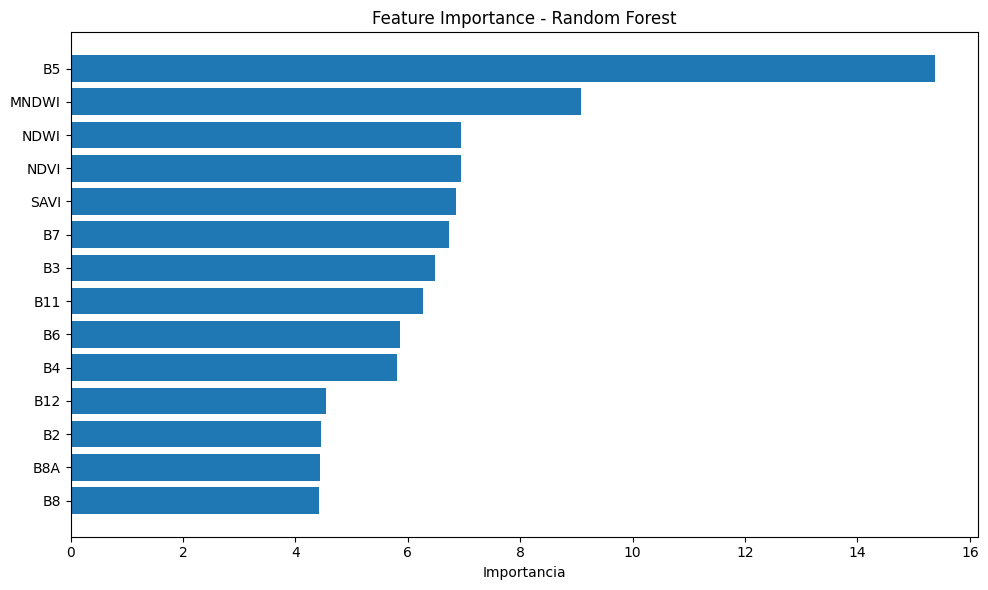

In [65]:
# --- Importancia de variables (Feature Importance) ---
importance = classifier.explain().getInfo()

if 'importance' in str(importance):
    fi = importance.get('importance', {})
    if fi:
        sorted_fi = sorted(fi.items(), key=lambda x: x[1], reverse=True)
        names = [x[0] for x in sorted_fi]
        values = [x[1] for x in sorted_fi]

        plt.figure(figsize=(10, 6))
        plt.barh(names[:15], values[:15])
        plt.xlabel('Importancia')
        plt.title('Feature Importance - Random Forest')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print('Feature importance no disponible para este clasificador')